# 01 — Project Setup and Data Exploration

This notebook performs a **read-only** audit of the Ahmedabad–Gandhinagar Sentinel-2 land-cover project. It inspects the area of interest (AOI), raster metadata, expected outputs, and labelled training table. It does not create or overwrite project data.

**Run from:** the repository root or `notebooks/` directory.  
**AOI file:** `data/aoi/study_area.geojson`  
**Important:** raster CRS and resolution are read from each file's metadata; do not infer them from filenames.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd

# Resolve the repository root whether Jupyter starts in the root or notebooks/.
CWD = Path.cwd().resolve()
if (CWD / "data").is_dir() and (CWD / "outputs").is_dir():
    PROJECT_ROOT = CWD
elif CWD.name.lower() == "notebooks" and (CWD.parent / "data").is_dir():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError(
        "Cannot locate the project root. Start Jupyter from the repository root or its notebooks/ folder."
    )

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
print("Project root:", PROJECT_ROOT)
print("Python package versions:")
print("  NumPy:", np.__version__)
print("  Pandas:", pd.__version__)
print("  Rasterio:", rasterio.__version__)
print("  GeoPandas:", gpd.__version__)

Project root: C:\Users\lenovo\Desktop\satellite-land-cover-classification
Python package versions:
  NumPy: 2.5.3
  Pandas: 3.0.6
  Rasterio: 1.5.2
  GeoPandas: 1.2.0


## 1. Load and validate the area of interest

The AOI's declared CRS is used as the source CRS. The notebook checks for empty or invalid geometries and reports the bounds. It does **not** silently assign a CRS if the file is missing one.

In [2]:
aoi_path = DATA_DIR / "aoi" / "study_area.geojson"
if not aoi_path.exists():
    raise FileNotFoundError(f"AOI file not found: {aoi_path}")

aoi = gpd.read_file(aoi_path)
if aoi.empty:
    raise ValueError("AOI file contains no features.")
if aoi.crs is None:
    raise ValueError("AOI CRS is missing. Verify the source CRS before continuing.")

# Drop Z coordinates when supported; this analysis uses 2D polygon geometry.
if hasattr(aoi.geometry, "force_2d"):
    aoi = aoi.set_geometry(aoi.geometry.force_2d())

invalid_count = int((~aoi.geometry.is_valid).sum())
empty_count = int(aoi.geometry.is_empty.sum())
print("Feature count:", len(aoi))
print("Declared CRS:", aoi.crs)
print("Geometry types:", aoi.geometry.geom_type.value_counts().to_dict())
print("Invalid geometries:", invalid_count)
print("Empty geometries:", empty_count)
print("Bounds in source CRS:", aoi.total_bounds)
if invalid_count or empty_count:
    print("WARNING: inspect the AOI geometry before relying on area or overlay results.")
display(aoi.drop(columns="geometry", errors="ignore"))

Feature count: 1
Declared CRS: EPSG:4326
Geometry types: {'Polygon': 1}
Invalid geometries: 0
Empty geometries: 0
Bounds in source CRS: [72.55744464 23.15596316 72.60813514 23.18032797]


,fid,name
0,1,Ahmedabad_Gandhinagar_AOI


## 2. Visualize the AOI in geographic coordinates

For meaningful longitude/latitude axis labels, the geometry is reprojected to EPSG:4326 for plotting only. This does not change the source GeoJSON.

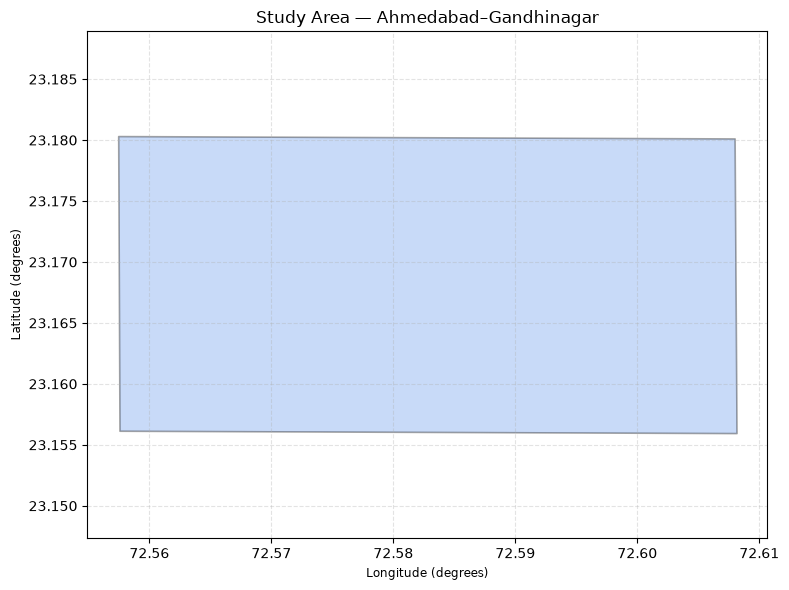

In [3]:
aoi_geo = aoi.to_crs("EPSG:4326")
fig, ax = plt.subplots(figsize=(8, 6))
aoi_geo.plot(ax=ax, facecolor="cornflowerblue", edgecolor="black", alpha=0.35, linewidth=1.2)
ax.set_title("Study Area — Ahmedabad–Gandhinagar")
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Latitude (degrees)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()

## 3. Estimate AOI area

Area is calculated after projecting the AOI into a metre-based CRS. EPSG:32643 is used here for a local area estimate around Ahmedabad–Gandhinagar; the source AOI is not modified. Always inspect the CRS of each input raster independently.

In [4]:
AREA_CRS = "EPSG:32643"
aoi_metric = aoi.to_crs(AREA_CRS)
area_m2 = float(aoi_metric.geometry.area.sum())
print("Area calculation CRS:", AREA_CRS)
print(f"AOI area: {area_m2:,.0f} m²")
print(f"AOI area: {area_m2 / 1_000_000:.3f} km²")
print("Note: this is the sum of feature areas; overlapping AOI features would be counted more than once.")

Area calculation CRS: EPSG:32643
AOI area: 13,867,893 m²
AOI area: 13.868 km²
Note: this is the sum of feature areas; overlapping AOI features would be counted more than once.


## 4. Inventory available raster files

This read-only inventory scans `data/`, `outputs/indices/`, and `outputs/classification/`. It reports metadata for each GeoTIFF. Differences in CRS, resolution, dimensions, or bounds may be important before combining rasters.

In [5]:
raster_roots = [DATA_DIR, OUTPUTS_DIR / "indices", OUTPUTS_DIR / "classification"]
raster_paths = sorted({
    p for root in raster_roots if root.exists()
    for p in root.rglob("*") if p.is_file() and p.suffix.lower() in {".tif", ".tiff"}
})

records = []
for path in raster_paths:
    try:
        with rasterio.open(path) as src:
            records.append({
                "file": str(path.relative_to(PROJECT_ROOT)),
                "width": src.width,
                "height": src.height,
                "bands": src.count,
                "crs": str(src.crs) if src.crs else None,
                "resolution_x": src.res[0],
                "resolution_y": src.res[1],
                "bounds": tuple(src.bounds),
                "nodata": src.nodata,
                "dtype": src.dtypes[0] if src.count else None,
            })
    except Exception as exc:
        records.append({"file": str(path.relative_to(PROJECT_ROOT)), "error": repr(exc)})

raster_inventory = pd.DataFrame(records)
if raster_inventory.empty:
    print("No GeoTIFF files found in the scanned folders.")
else:
    display(raster_inventory)
    print("\nCRS values present:", raster_inventory.get("crs", pd.Series(dtype=str)).dropna().unique().tolist())
    print("Check raster alignment before pixel-wise comparisons or model inference.")

,file,width,height,bands,crs,resolution_x,resolution_y,bounds,nodata,dtype
0,data\processed\sentinel2\aligned_10m\T42QZL_20...,528,280,1,EPSG:32642,10.0,10.0,"(864240.0, 2565250.0, 869520.0, 2568050.0)",0.0,float32
1,data\processed\sentinel2\aligned_10m\T42QZL_20...,528,280,1,EPSG:32642,10.0,10.0,"(864240.0, 2565250.0, 869520.0, 2568050.0)",0.0,float32
2,data\processed\sentinel2\aligned_10m\T42QZL_20...,528,280,1,EPSG:32642,10.0,10.0,"(864240.0, 2565250.0, 869520.0, 2568050.0)",0.0,float32
3,data\processed\sentinel2\aligned_10m\T42QZL_20...,528,280,1,EPSG:32642,10.0,10.0,"(864240.0, 2565250.0, 869520.0, 2568050.0)",0.0,float32
4,data\processed\sentinel2\aligned_10m\T42QZL_20...,528,280,1,EPSG:32642,10.0,10.0,"(864240.0, 2565250.0, 869520.0, 2568050.0)",0.0,float32
5,data\processed\sentinel2\aligned_10m\T42QZL_20...,528,280,1,EPSG:32642,10.0,10.0,"(864240.0, 2565250.0, 869520.0, 2568050.0)",0.0,float32
6,data\processed\sentinel2\T42QZL_20261003T05365...,528,280,1,EPSG:32642,10.0,10.0,"(864240.0, 2565250.0, 869520.0, 2568050.0)",0.0,uint16
7,data\processed\sentinel2\T42QZL_20261003T05365...,528,280,1,EPSG:32642,10.0,10.0,"(864240.0, 2565250.0, 869520.0, 2568050.0)",0.0,uint16
8,data\processed\sentinel2\T42QZL_20261003T05365...,528,280,1,EPSG:32642,10.0,10.0,"(864240.0, 2565250.0, 869520.0, 2568050.0)",0.0,uint16
9,data\processed\sentinel2\T42QZL_20261003T05365...,264,141,1,EPSG:32642,20.0,20.0,"(864240.0, 2565240.0, 869520.0, 2568060.0)",0.0,uint16



CRS values present: ['EPSG:32642']
Check raster alignment before pixel-wise comparisons or model inference.


## 5. Check key project artifacts

Missing files are reported rather than generated. Some outputs are optional depending on which workflow stages have been run.

In [6]:
expected_paths = [
    PROJECT_ROOT / "outputs" / "training_dataset.csv",
    PROJECT_ROOT / "outputs" / "training" / "spectral_features.npz",
    PROJECT_ROOT / "outputs" / "indices" / "ndvi.tif",
    PROJECT_ROOT / "outputs" / "indices" / "ndwi.tif",
    PROJECT_ROOT / "outputs" / "indices" / "ndbi.tif",
    PROJECT_ROOT / "outputs" / "reports" / "model_comparison.csv",
    PROJECT_ROOT / "outputs" / "reports" / "spatial_cv_fold_metrics.csv",
    PROJECT_ROOT / "outputs" / "figures" / "land_cover_classification_final.png",
    PROJECT_ROOT / "outputs" / "reports" / "land_cover_final_report.pdf",
]
artifact_table = pd.DataFrame([
    {"artifact": str(p.relative_to(PROJECT_ROOT)), "exists": p.exists(),
     "size_bytes": p.stat().st_size if p.exists() and p.is_file() else None}
    for p in expected_paths
])
display(artifact_table)

,artifact,exists,size_bytes
0,outputs\training_dataset.csv,True,5752
1,outputs\training\spectral_features.npz,True,3610119
2,outputs\indices\ndvi.tif,True,496165
3,outputs\indices\ndwi.tif,True,484879
4,outputs\indices\ndbi.tif,True,510884
5,outputs\reports\model_comparison.csv,True,319
6,outputs\reports\spatial_cv_fold_metrics.csv,True,293
7,outputs\figures\land_cover_classification_fina...,True,285688
8,outputs\reports\land_cover_final_report.pdf,True,251265


## 6. Inspect the labelled training table

This section reports the table shape, missing values, duplicate rows, and class counts. These checks describe the available samples; they do not establish that labels are correct or spatially representative.

Shape: (39, 16)
Columns: ['sample_id', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI', 'class_name', 'class_id']
Duplicate complete rows: 0
Missing values by column:


,status
0,No missing values detected


,sample_id,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12,NDVI,NDWI,NDBI,class_name,class_id
0,1,1265.0,1529.0,1316.0,1536.0,1302.0,1366.0,1317.0,1304.0,1322.0,1213.0,0.000380,0.074491,0.000356,vegetation,1
1,2,2820.0,3045.0,3335.0,3636.0,3714.0,3632.0,3557.0,3804.0,4173.0,3825.0,0.032211,-0.077552,0.058629,built_up,2
2,3,1678.0,2019.0,2395.0,2639.0,2754.0,2907.0,2871.0,3090.0,3876.0,3542.0,0.090391,-0.174233,0.154127,bare_soil,3
3,4,1256.0,1347.0,1219.0,1256.0,1289.0,1268.0,1325.0,1366.0,1347.0,1251.0,0.041667,0.008234,0.007955,water,4
4,5,1717.0,1801.0,1895.0,1984.0,2045.0,2099.0,2060.0,2175.0,2293.0,2071.0,0.041719,-0.067081,0.073129,road,5


,sample_count,share_percent
class_name,,
vegetation,10,25.641026
built_up,9,23.076923
road,8,20.512821
bare_soil,6,15.384615
water,6,15.384615


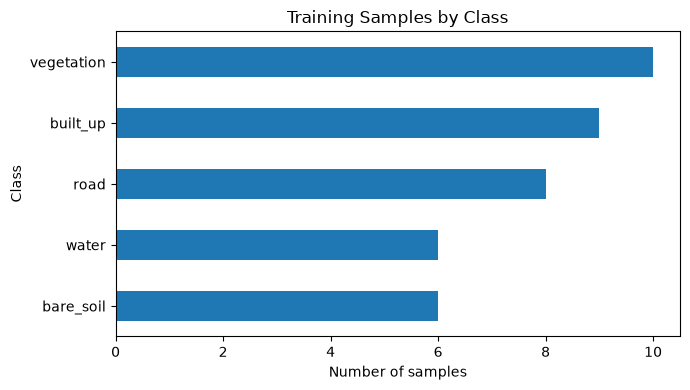

In [7]:
training_csv = OUTPUTS_DIR / "training_dataset.csv"
if not training_csv.exists():
    print(f"Training table not found: {training_csv.relative_to(PROJECT_ROOT)}")
else:
    training = pd.read_csv(training_csv)
    print("Shape:", training.shape)
    print("Columns:", training.columns.tolist())
    print("Duplicate complete rows:", int(training.duplicated().sum()))
    missing = training.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print("Missing values by column:")
    display(missing.rename("missing_count").to_frame() if not missing.empty else pd.DataFrame({"status": ["No missing values detected"]}))
    display(training.head())

    if "class_name" in training.columns:
        class_counts = training["class_name"].value_counts(dropna=False).rename_axis("class_name").to_frame("sample_count")
        class_counts["share_percent"] = 100 * class_counts["sample_count"] / len(training)
        display(class_counts)
        ax = class_counts["sample_count"].sort_values().plot(kind="barh", figsize=(7, 4))
        ax.set_title("Training Samples by Class")
        ax.set_xlabel("Number of samples")
        ax.set_ylabel("Class")
        plt.tight_layout()
        plt.show()
    else:
        print("No 'class_name' column found; skipping class-count summary.")

## 7. Next steps and interpretation

- `02_spectral_indices.ipynb` — inspect NDVI, NDWI, and NDBI.
- `03_training_data_analysis.ipynb` — inspect labelled samples, feature distributions, and spatial grouping.
- `04_model_evaluation.ipynb` — review model metrics and validation limitations.
- `05_classification_visualization.ipynb` — inspect classification maps and class-area summaries.
- `06_aoi_transfer_test.ipynb` — document whether transfer testing is supported by available data.

**Scientific caution:** training-set cross-validation, visual plausibility, and predicted class-area percentages are not substitutes for independent, representative reference data. A transfer test should only be described as completed if a genuinely separate target area and suitable reference labels were evaluated.